In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import tifffile as tiff
from cellpose import models
from skimage.measure import regionprops_table

import torch

In [22]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs" / "cellpose_python"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COND_PATH = DATA_DIR / "raw_condensates" / "C2-ROI_raw_stack_sample2_5.tif"
NUC_PATH  = DATA_DIR / "raw_nuclei" / "C1-ROI_raw_stack_sample2_5.tif"

print("Condensate file exists: ", COND_PATH.exists())
print("Nuclei file exists: ", NUC_PATH.exists())

Condensate file exists:  True
Nuclei file exists:  True


In [23]:
cond_stack = tiff.imread(COND_PATH)
nuc_stack = tiff.imread(NUC_PATH)

print("Condensates shape:", cond_stack.shape)
print("Nuclei shape:", nuc_stack.shape)
print("Condensates dtype:", cond_stack.dtype)
print("Nuclei dtype:", nuc_stack.dtype)

Condensates shape: (55, 185, 259)
Nuclei shape: (55, 185, 259)
Condensates dtype: uint16
Nuclei dtype: uint16


In [24]:
cond_model = models.CellposeModel(gpu=True)
nuc_model  = models.CellposeModel(gpu=True)

In [25]:
from cellpose import core
print("GPU working:", core.use_gpu())
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
print("Current device:", torch.cuda.current_device())
print("GPU name:", torch.cuda.get_device_name(torch.cuda.current_device()))


GPU working: True
CUDA available: True
GPU count: 1
Current device: 0
GPU name: NVIDIA GeForce RTX 4080


In [26]:
def run_cellpose_stack(stack, model, object_name="objects", diameter=None):
    mask_stack = []
    measurements = []

    for z in range(stack.shape[0]):
        img = stack[z]

        masks, flows, styles = model.eval(
            img,
            diameter=diameter,
        )

        mask_stack.append(masks.astype(np.int32))

        props = regionprops_table(
            masks,
            intensity_image=img,
            properties=["label", "area", "centroid", "mean_intensity"]
        )

        df = pd.DataFrame(props)
        if not df.empty:
            df["z"] = z
        else:
            df = pd.DataFrame(columns=["label", "area", "centroid-0", "centroid-1", "mean_intensity", "z"])

        measurements.append(df)

        print(f"{object_name} slice {z}: {masks.max()} objects")

    mask_stack = np.stack(mask_stack)
    measurements_df = pd.concat(measurements, ignore_index=True)

    return mask_stack, measurements_df

In [27]:
cond_masks, cond_df = run_cellpose_stack(
    cond_stack,
    cond_model,
    object_name="condensates",
    diameter=None
)

condensates slice 0: 0 objects
condensates slice 1: 0 objects
condensates slice 2: 0 objects
condensates slice 3: 0 objects
condensates slice 4: 0 objects
condensates slice 5: 0 objects
condensates slice 6: 2 objects
condensates slice 7: 3 objects
condensates slice 8: 3 objects
condensates slice 9: 3 objects
condensates slice 10: 3 objects
condensates slice 11: 0 objects
condensates slice 12: 0 objects
condensates slice 13: 0 objects
condensates slice 14: 2 objects
condensates slice 15: 4 objects
condensates slice 16: 5 objects
condensates slice 17: 7 objects
condensates slice 18: 7 objects
condensates slice 19: 8 objects
condensates slice 20: 7 objects
condensates slice 21: 8 objects
condensates slice 22: 6 objects
condensates slice 23: 5 objects
condensates slice 24: 6 objects
condensates slice 25: 6 objects
condensates slice 26: 9 objects
condensates slice 27: 6 objects
condensates slice 28: 5 objects
condensates slice 29: 6 objects
condensates slice 30: 6 objects
condensates slice 

C:\Users\Danie\AppData\Local\Temp\ipykernel_24340\3295554899.py:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  measurements_df = pd.concat(measurements, ignore_index=True)


In [28]:
nuc_masks, nuc_df = run_cellpose_stack(
    nuc_stack,
    nuc_model,
    object_name="nuclei",
    diameter=None
)

nuclei slice 0: 0 objects
nuclei slice 1: 0 objects
nuclei slice 2: 0 objects
nuclei slice 3: 0 objects
nuclei slice 4: 0 objects
nuclei slice 5: 5 objects
nuclei slice 6: 8 objects
nuclei slice 7: 7 objects
nuclei slice 8: 8 objects
nuclei slice 9: 8 objects
nuclei slice 10: 8 objects
nuclei slice 11: 8 objects
nuclei slice 12: 8 objects
nuclei slice 13: 8 objects
nuclei slice 14: 8 objects
nuclei slice 15: 8 objects
nuclei slice 16: 8 objects
nuclei slice 17: 8 objects
nuclei slice 18: 8 objects
nuclei slice 19: 8 objects
nuclei slice 20: 8 objects
nuclei slice 21: 8 objects
nuclei slice 22: 8 objects
nuclei slice 23: 7 objects
nuclei slice 24: 7 objects
nuclei slice 25: 7 objects
nuclei slice 26: 8 objects
nuclei slice 27: 8 objects
nuclei slice 28: 8 objects
nuclei slice 29: 8 objects
nuclei slice 30: 7 objects
nuclei slice 31: 8 objects
nuclei slice 32: 8 objects
nuclei slice 33: 8 objects
nuclei slice 34: 8 objects
nuclei slice 35: 8 objects
nuclei slice 36: 8 objects
nuclei slic

C:\Users\Danie\AppData\Local\Temp\ipykernel_24340\3295554899.py:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  measurements_df = pd.concat(measurements, ignore_index=True)


In [29]:
print("Condensate mask stack shape:", cond_masks.shape)
print("Nuclei mask stack shape:", nuc_masks.shape)

display(cond_df.head())
display(nuc_df.head())

Condensate mask stack shape: (55, 185, 259)
Nuclei mask stack shape: (55, 185, 259)


,label,area,centroid-0,centroid-1,mean_intensity,z
0,1,2224.0,68.973471,202.438849,166.559802,6
1,2,2174.0,99.742870,38.040018,164.749310,6
2,1,4559.0,65.389998,118.272428,178.129414,7
3,2,3934.0,72.963650,209.268429,178.141332,7
4,3,1748.0,99.469680,41.434783,179.867849,7


,label,area,centroid-0,centroid-1,mean_intensity,z
0,1,4368.0,63.141255,189.924451,197.011218,5
1,2,5288.0,82.035174,92.113086,195.344554,5
2,3,2147.0,133.017699,14.792268,192.090359,5
3,4,5321.0,142.345236,142.017666,206.760571,5
4,5,1689.0,143.718176,239.767910,174.387211,5


In [ ]:
# partition coefficient calculaton

cond_pixels_all = []
dilute_pixels_all = []

for z in range(cond_stack.shape[0]):
    cond_mask = cond_masks[z] > 0
    nuc_mask  = nuc_masks[z] > 0
    img = cond_stack[z]

    cond_pixels = img[cond_mask & nuc_mask]
    dilute_pixels = img[nuc_mask & (~cond_mask)]

    if cond_pixels.size > 0:
        cond_pixels_all.append(cond_pixels)

    if dilute_pixels.size > 0:
        dilute_pixels_all.append(dilute_pixels)

cond_density = np.mean(np.concatenate(cond_pixels_all))
dilute_density = np.mean(np.concatenate(dilute_pixels_all))
partition_coefficient = cond_density / dilute_density

print("Condensate density:", cond_density)
print("Dilute density:", dilute_density)
print("Partition coefficient:", partition_coefficient)

Condensate density: 337.87323014463334
Dilute density: 165.30731052598532
Partition coefficient: 2.0439097888022424


In [31]:
tiff.imwrite(OUTPUT_DIR / "ROI_condensate_masks.tif", cond_masks.astype(np.int32))
tiff.imwrite(OUTPUT_DIR / "ROI_nuclei_masks.tif", nuc_masks.astype(np.int32))

cond_df.to_csv(OUTPUT_DIR / "ROI_condensate_measurements.csv", index=False)
nuc_df.to_csv(OUTPUT_DIR / "ROI_nuclei_measurements.csv", index=False)

print("Saved to:", OUTPUT_DIR)

Saved to: c:\storage\code\research\outputs\cellpose_python


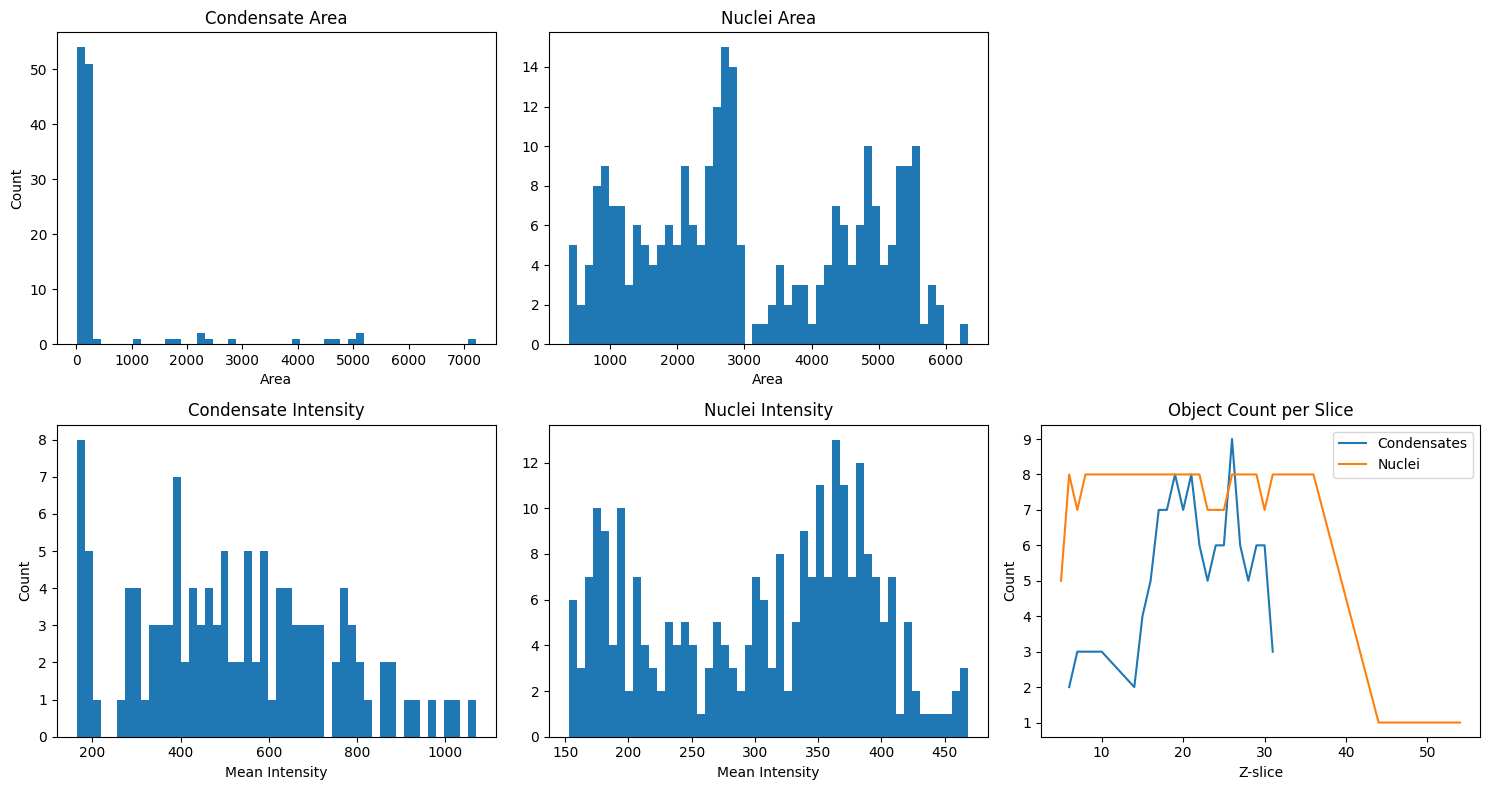

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 3, figsize=(15, 8))

axs[0,0].hist(cond_df["area"], bins=50)
axs[0,0].set_title("Condensate Area")
axs[0,0].set_xlabel("Area")
axs[0,0].set_ylabel("Count")

axs[0,1].hist(nuc_df["area"], bins=50)
axs[0,1].set_title("Nuclei Area")
axs[0,1].set_xlabel("Area")

axs[0,2].axis("off")

axs[1,0].hist(cond_df["mean_intensity"], bins=50)
axs[1,0].set_title("Condensate Intensity")
axs[1,0].set_xlabel("Mean Intensity")
axs[1,0].set_ylabel("Count")

axs[1,1].hist(nuc_df["mean_intensity"], bins=50)
axs[1,1].set_title("Nuclei Intensity")
axs[1,1].set_xlabel("Mean Intensity")

cond_counts = cond_df.groupby("z")["label"].count()
nuc_counts = nuc_df.groupby("z")["label"].count()

axs[1,2].plot(cond_counts.index, cond_counts.values, label="Condensates")
axs[1,2].plot(nuc_counts.index, nuc_counts.values, label="Nuclei")
axs[1,2].set_title("Object Count per Slice")
axs[1,2].set_xlabel("Z-slice")
axs[1,2].set_ylabel("Count")
axs[1,2].legend()

plt.tight_layout()
plt.show()